This notebook includes initial results on preliminary dataset exploration (to be used in project proposal).  
Plots included in this notebook: a donor bar plot, a cell-type bar plot, a donor x cell-type heatmap, and UMAP colored by patient ID and cell type. 

In [4]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**Read in Data (Run either of the Blocks)**

In [ ]:
import pertpy as pt
adata = pt.data.stephenson_2021_subsampled()

In [2]:
adata = ad.read_h5ad("/users/xchen5/scRNA-cross-donor-generalization/data/stephenson_2021_subsampled.h5ad") # for local loads, if pertpy does not work

**Filter Data to Control Samples, 500 Cells Each**

In [ ]:
# RE-USE this script in all notebooks
# focus on healthy control samples only - in the dataset, this is the "Healthy" classification in "status" column (exclues COVID and LPS samples)
# in addition, each sample should only contain 500 cells for fairness in comparison across donors
adata_ctrl = adata[adata.obs["Status"] == "Healthy"].copy()

# downsample to 500 cells per donor if there are more than 500 cells for that donor, otherwise keep all cells for that donor
cells_to_keep = []

for donor, idx in adata_ctrl.obs.groupby("patient_id", observed=True).groups.items():
    idx = np.array(list(idx))
    
    if len(idx) > 500:
        cells_to_keep.extend(np.random.choice(idx, 500, replace=False))
    else:
        cells_to_keep.extend(idx)

adata_ctrl = adata_ctrl[cells_to_keep].copy()

print("Control cells:", adata_ctrl.n_obs)
print("Control donors:", adata_ctrl.obs["patient_id"].nunique())

Control cells: 11290
Control donors: 23


In [11]:
# check the distribution of donors and cell types in the control samples
donor_col = "patient_id"
celltype_col = "cell_type"
print(adata_ctrl.obs[donor_col].value_counts().head())
print(adata_ctrl.obs[celltype_col].value_counts().head())

patient_id
CV0902    500
CV0904    500
CV0911    500
CV0915    500
CV0917    500
Name: count, dtype: int64
cell_type
CD16-positive, CD56-dim natural killer cell, human      1585
naive thymus-derived CD4-positive, alpha-beta T cell    1482
CD14-positive monocyte                                  1164
central memory CD4-positive, alpha-beta T cell          1114
naive thymus-derived CD8-positive, alpha-beta T cell     786
Name: count, dtype: int64


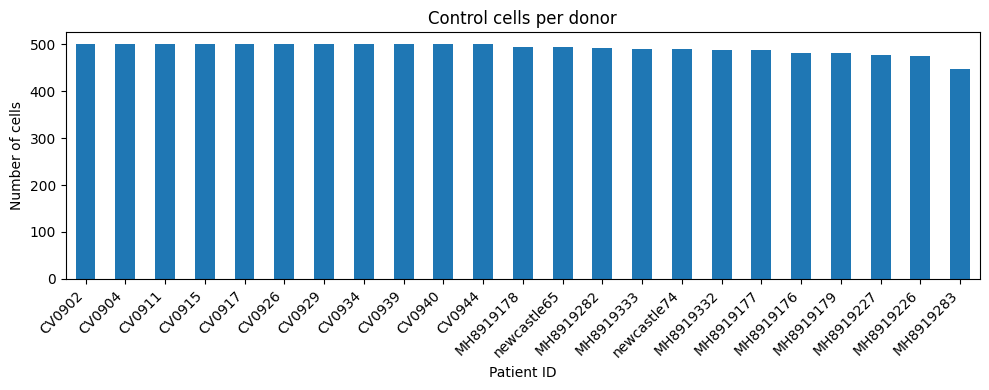

In [12]:
plt.figure(figsize=(10, 4))
adata_ctrl.obs[donor_col].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Control cells per donor")
plt.xlabel("Patient ID")
plt.ylabel("Number of cells")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

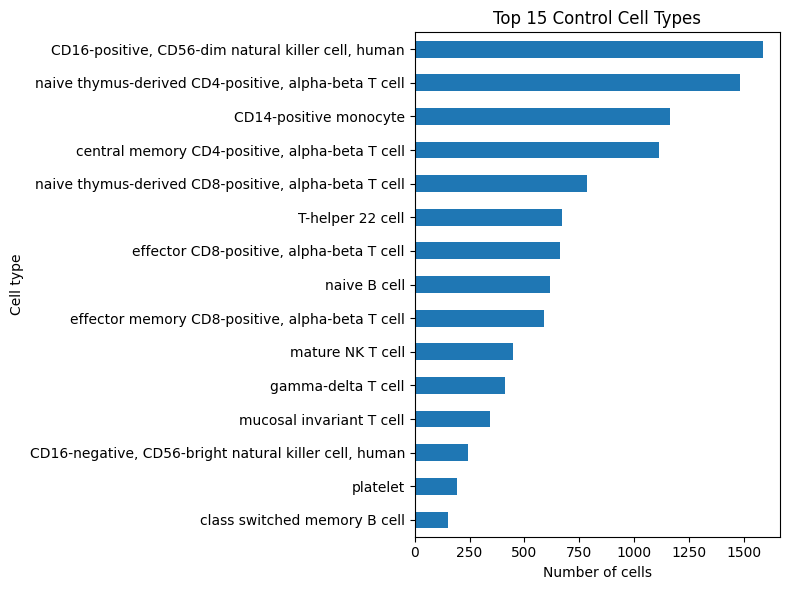

In [13]:
# get counts
counts = adata_ctrl.obs[celltype_col].value_counts()

# keep top 15
top_counts = counts.head(15)

plt.figure(figsize=(8, 6))
top_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Control Cell Types")
plt.xlabel("Number of cells")
plt.ylabel("Cell type")

plt.tight_layout()
plt.show()

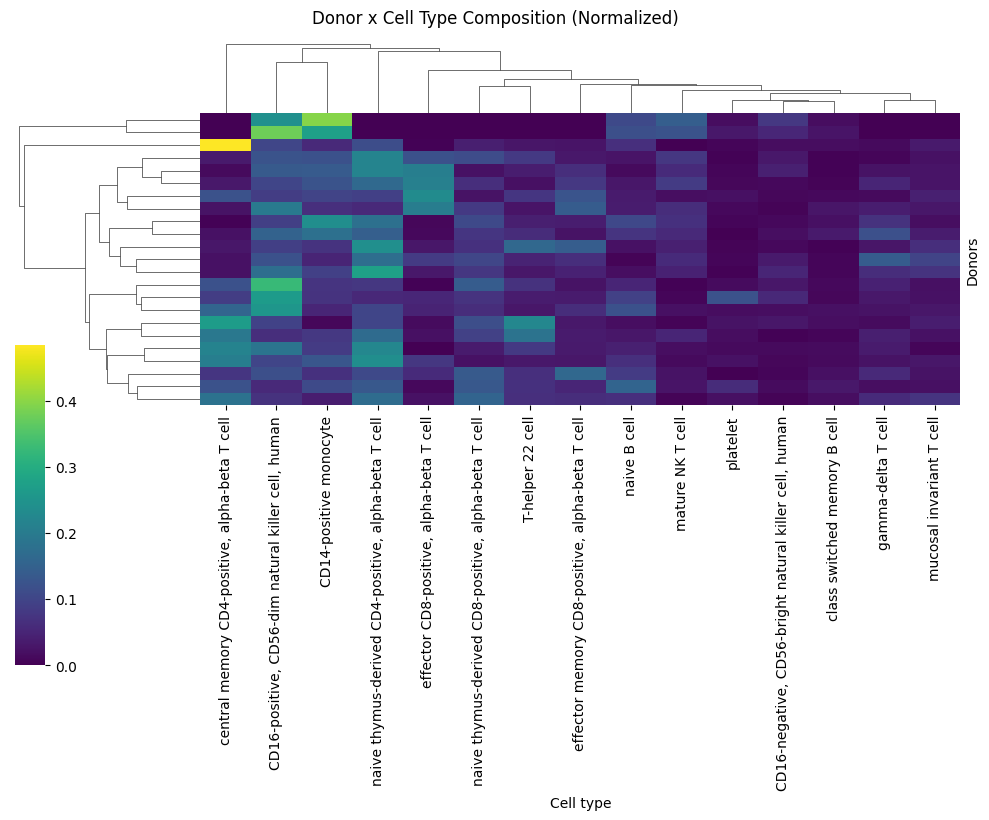

In [14]:
# crosstab
ct = pd.crosstab(
    adata_ctrl.obs[donor_col],
    adata_ctrl.obs[celltype_col]
)

# keep top 15 cell types globally
top_celltypes = ct.sum(axis=0).sort_values(ascending=False).head(15).index
ct = ct[top_celltypes]

# normalize per donor (row-wise proportions)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# clustered heatmap
g = sns.clustermap(
    ct_norm,
    cmap="viridis",
    figsize=(10, 8),
    metric="euclidean",
    method="average",
    yticklabels=False,
    cbar_pos=(0.02, 0.2, 0.03, 0.4)
)

g.ax_heatmap.set_xlabel("Cell type")
g.ax_heatmap.set_ylabel("Donors")

plt.suptitle("Donor x Cell Type Composition (Normalized)", y=1.02)
plt.show()

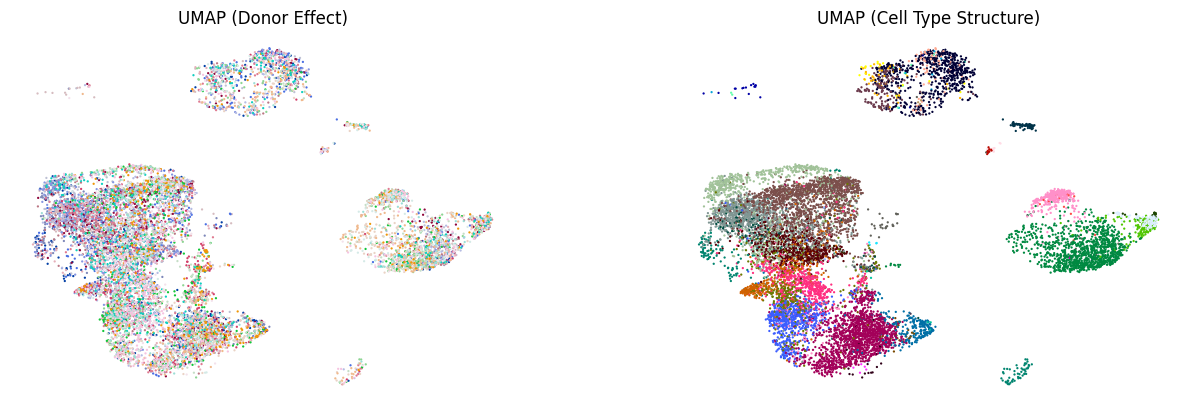

In [15]:
sc.pl.umap(
    adata_ctrl,
    color=[donor_col, celltype_col],
    title=["UMAP (Donor Effect)", "UMAP (Cell Type Structure)"],
    frameon=False,
    wspace=0.2,
    legend_loc=None 
)